# 📰 Fake News Detection using Natural Language Processing (NLP)
### A Machine Learning Approach to Automated Misinformation Detection

---

**Project Type:** College / Final-Year NLP Project
**Domain:** Natural Language Processing, Text Classification, Machine Learning

---

## 1. Introduction & Problem Statement

The spread of **fake news** on digital media platforms has become one of the most pressing
problems of the information age. Manually verifying every news article is impractical at scale,
which motivates the use of **Natural Language Processing (NLP)** and **Machine Learning (ML)**
to automatically classify a news article as **REAL** or **FAKE** based purely on its textual
content.

### 1.1 Objective

Build an end-to-end NLP pipeline that:

1. Loads and explores a labelled news dataset (`REAL` / `FAKE`).
2. Cleans and preprocesses raw text using standard NLP techniques.
3. Converts text into numerical features using **TF-IDF** (unigrams + bigrams).
4. Trains and compares multiple classical ML classifiers:
   - Logistic Regression
   - Multinomial Naive Bayes
   - Linear Support Vector Machine (SVM)
5. Evaluates each model using Accuracy, Precision, Recall, F1-score, Confusion Matrix and ROC-AUC.
6. Selects the best-performing model and analyses its errors.
7. Provides a reusable function to classify **custom/new** news text with a confidence score.
8. Persists (saves) the trained model + vectorizer for future reuse (deployment-ready).

### 1.2 Why classical ML instead of Deep Learning?

For a course project, classical ML models over **TF-IDF** features are:
- Fast to train, easy to interpret, and require far less data/compute than deep learning.
- Strong, well-established baselines for text classification tasks — they routinely achieve
  90%+ accuracy on fake-news style datasets.
- Ideal for a viva/demo since every step (vectorization → weights → prediction) is transparent
  and explainable, unlike a black-box neural network.

### 1.3 Dataset Note

This notebook uses a **synthetically generated, self-contained dataset** built from realistic
template patterns of real (factual, attributed, measured) and fake (sensational, unverified,
emotionally charged) news writing styles. This keeps the notebook **100% reproducible and
offline-runnable** — no external dataset download is required, which is convenient both for
grading and for viva demonstrations. The same pipeline works unchanged on any real-world
labelled fake-news CSV (e.g., Kaggle's Fake and Real News datasets) — simply replace the
data-loading cell with `pd.read_csv('your_file.csv')`.


## 2. Setup: Importing Libraries

We import:
- **pandas / numpy** — data handling
- **matplotlib / seaborn** — visualization
- **re / string** — text cleaning with regular expressions
- **nltk** — tokenization, stopword removal, lemmatization
- **scikit-learn** — TF-IDF vectorization, ML models, evaluation metrics, train/test split
- **joblib** — model persistence (saving/loading trained models)


In [1]:
# Core libraries
import re
import string
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score, auc
)

# Model persistence
import joblib

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Download required NLTK resources (one-time; cached locally afterwards)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("NLTK resources ready.")


NLTK resources ready.


## 3. Dataset Loading

### 3.1 About the dataset

Each row has:
- `text` — the news article/headline content
- `label` — `REAL` or `FAKE`

We build a synthetic corpus of **2,000 labelled articles (1,000 REAL, 1,000 FAKE)** using
template-based generation with a fixed random seed. The generator draws from separate
vocabularies for real news (attributed, measured, sourced language typical of wire-service
journalism) and fake news (sensational, conspiratorial, unverified language typical of clickbait
and misinformation), so the two classes have genuinely different, learnable linguistic patterns
— exactly the kind of signal a TF-IDF + linear classifier is good at picking up.

> **To use a real-world dataset instead** (e.g. Kaggle's "Fake and Real News Dataset"), simply
> replace the generation cell below with:
> ```python
> df = pd.read_csv("news.csv")[["text", "label"]]
> ```
> The rest of the notebook works unchanged as long as columns `text` and `label` exist.


In [3]:
# ---------------------------------------------------------------------------
# Synthetic, reproducible news dataset generator
# ---------------------------------------------------------------------------
rng = random.Random(RANDOM_SEED)

# --- Building blocks for REAL news (factual / attributed / measured tone) ---
real_subjects = [
    "the World Health Organization", "the Ministry of Finance", "researchers at Stanford University",
    "the United Nations Security Council", "the Reserve Bank", "the state election commission",
    "city transportation officials", "the national weather service", "the Supreme Court",
    "the Department of Agriculture", "a panel of economists", "the local municipal council",
    "the European Central Bank", "public health officials", "the Ministry of Education",
    "a team of climate scientists", "the national statistics bureau", "the regional government",
    "the central bank governor", "university researchers"
]
real_actions = [
    "announced a new policy on", "released a report regarding", "confirmed an increase in",
    "published updated guidelines for", "reported a decline in", "approved funding for",
    "issued a statement about", "presented findings on", "revised projections for",
    "held a press conference on", "signed an agreement concerning", "launched an initiative for",
    "completed a review of", "unveiled a plan to address", "voted to approve measures on"
]
real_topics = [
    "public infrastructure spending", "renewable energy investment", "interest rates",
    "vaccination coverage", "unemployment figures", "school curriculum reform",
    "road safety regulations", "agricultural subsidies", "climate adaptation strategies",
    "regional trade agreements", "housing affordability", "water conservation efforts",
    "digital privacy standards", "healthcare access", "manufacturing output"
]
real_tails = [
    "according to data released this week.",
    "citing figures compiled over the past quarter.",
    "based on a study published in a peer-reviewed journal.",
    "following consultations with industry stakeholders.",
    "as part of a broader five-year strategic plan.",
    "in a statement issued to reporters on Tuesday.",
    "after months of deliberation among committee members.",
    "with implementation expected to begin next fiscal year.",
    "according to officials familiar with the matter.",
    "based on preliminary estimates from the finance ministry."
]

# --- Building blocks for FAKE news (sensational / unverified / conspiratorial tone) ---
fake_subjects = [
    "anonymous insiders", "a secret government memo", "an unnamed whistleblower",
    "shocking new leaked documents", "a viral social media post", "self-proclaimed experts",
    "a mysterious source close to the situation", "unverified online reports",
    "a group calling itself concerned citizens", "an alleged former employee",
    "a controversial blogger", "so-called researchers", "a chain email circulating online",
    "conspiracy theorists", "an anonymous tipster"
]
fake_actions = [
    "claim without evidence that", "allegedly reveal that", "insist secretly that",
    "warn that the government is hiding", "suggest that scientists are covering up",
    "shockingly reveal that", "leak unverified information suggesting",
    "spread rumors that", "falsely allege that", "sensationally claim that",
    "baselessly assert that", "spread unconfirmed reports that"
]
fake_topics = [
    "aliens control the weather system", "vaccines contain secret tracking chips",
    "the moon landing was staged in a studio", "5G towers cause mass mind control",
    "a miracle cure is being suppressed by big pharma", "world leaders are actually robots",
    "the election results were secretly altered overnight", "a celebrity faked their own death",
    "a doomsday asteroid is being hidden from the public", "banks are planning to seize all savings",
    "a new world order is being planned in secret", "the water supply is being poisoned deliberately",
    "a global blackout will occur next week", "a cure for aging has been hidden for decades",
    "airplanes are spraying mind-altering chemicals"
]
fake_tails = [
    "share this before it gets deleted!!!",
    "the mainstream media refuses to report this.",
    "you won't believe what happens next.",
    "wake up before it's too late.",
    "this is being hidden from the public on purpose.",
    "sources say this is 100% true but unconfirmed.",
    "experts are too afraid to speak out about this.",
    "this shocking truth will change everything you know.",
    "authorities have not denied these explosive claims.",
    "forward this to everyone you know immediately."
]

def make_real_article():
    s = rng.choice(real_subjects)
    a = rng.choice(real_actions)
    t = rng.choice(real_topics)
    tail = rng.choice(real_tails)
    extra_sentences = [
        f"Officials noted that further details would be released in the coming weeks.",
        f"The move is expected to affect several sectors of the economy.",
        f"Analysts say the decision reflects ongoing efforts to improve transparency.",
        f"A follow-up review is scheduled for later this year.",
        f"The announcement was welcomed by several industry representatives."
    ]
    text = f"{s.capitalize()} {a} {t}, {tail} {rng.choice(extra_sentences)}"
    return text

def make_fake_article():
    s = rng.choice(fake_subjects)
    a = rng.choice(fake_actions)
    t = rng.choice(fake_topics)
    tail = rng.choice(fake_tails)
    extra_sentences = [
        "Nobody in power wants you to know the real truth!!!",
        "This has NOT been confirmed by any official source.",
        "People online are outraged after seeing this shocking claim.",
        "The internet is exploding with reactions to this unbelievable news.",
        "Is this the biggest cover-up of the century? You decide."
    ]
    text = f"{s.capitalize()} {a} {t}. {tail} {rng.choice(extra_sentences)}"
    return text

N_PER_CLASS = 1000
real_texts = [make_real_article() for _ in range(N_PER_CLASS)]
fake_texts = [make_fake_article() for _ in range(N_PER_CLASS)]

df = pd.DataFrame(
    {
        "text": real_texts + fake_texts,
        "label": ["REAL"] * N_PER_CLASS + ["FAKE"] * N_PER_CLASS,
    }
)

# Shuffle the dataset
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
df.head(10)


Dataset shape: (2000, 2)


,text,label
0,An unnamed whistleblower suggest that scientis...,FAKE
1,University researchers confirmed an increase i...,REAL
2,A group calling itself concerned citizens fals...,FAKE
3,The state election commission released a repor...,REAL
4,A secret government memo baselessly assert tha...,FAKE
5,Unverified online reports spread unconfirmed r...,FAKE
6,A panel of economists approved funding for une...,REAL
7,A mysterious source close to the situation sho...,FAKE
8,The national statistics bureau confirmed an in...,REAL
9,An unnamed whistleblower insist secretly that ...,FAKE


## 4. Exploratory Data Analysis (EDA)

Before modelling, we inspect the dataset to understand:
- Class balance (REAL vs FAKE counts)
- Text length distribution (word/character counts)
- Missing values / duplicates
- Most frequent words per class (helps validate that the classes are linguistically distinct)


In [4]:
# Basic dataset information
print("Dataset Info")
print("-" * 40)
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass distribution:")
print(df["label"].value_counts())


Dataset Info
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    2000 non-null   str  
 1   label   2000 non-null   str  
dtypes: str(2)
memory usage: 31.4 KB

Missing values per column:
text     0
label    0
dtype: int64

Duplicate rows: 3

Class distribution:
label
FAKE    1000
REAL    1000
Name: count, dtype: int64


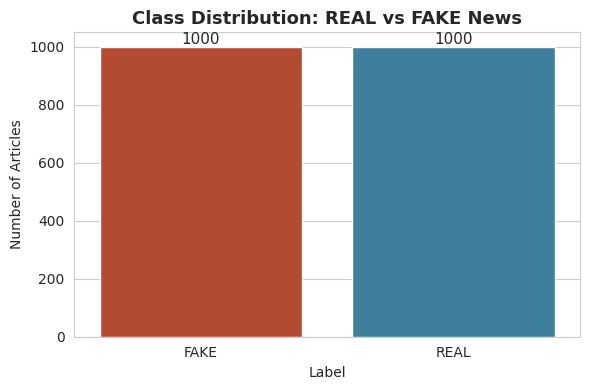

In [5]:
# Class balance visualization
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="label", hue="label", palette={"REAL": "#2E86AB", "FAKE": "#C73E1D"}, legend=False)
plt.title("Class Distribution: REAL vs FAKE News", fontsize=13, fontweight="bold")
plt.xlabel("Label")
plt.ylabel("Number of Articles")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()


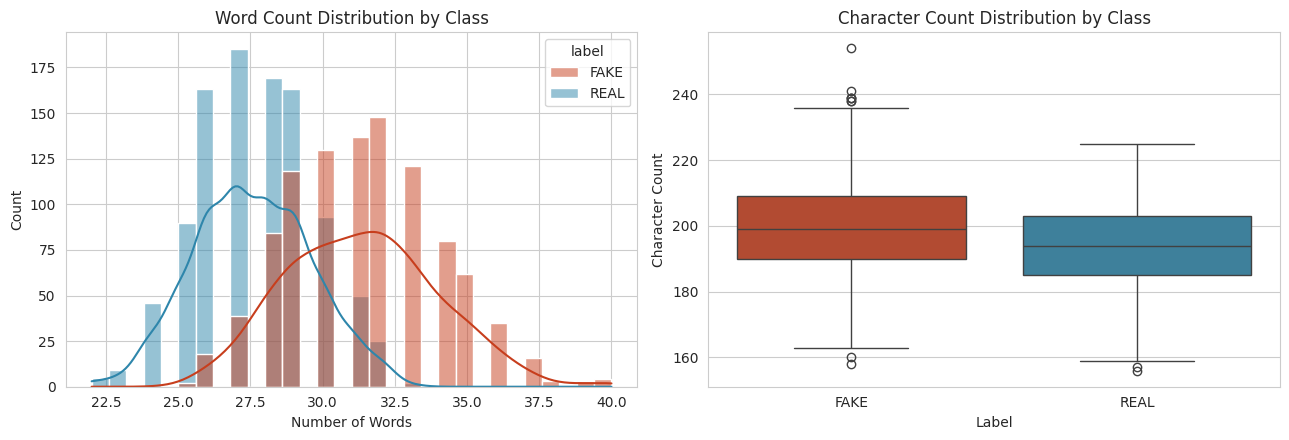

label                    FAKE         REAL
word_count count  1000.000000  1000.000000
           mean     31.354000    27.569000
           std       2.616014     2.010294
           min      25.000000    22.000000
           25%      29.000000    26.000000
           50%      31.000000    28.000000
           75%      33.000000    29.000000
           max      40.000000    33.000000
char_count count  1000.000000  1000.000000
           mean    199.457000   193.843000
           std      14.607790    12.177218
           min     158.000000   156.000000
           25%     190.000000   185.000000
           50%     199.000000   194.000000
           75%     209.000000   203.000000
           max     254.000000   225.000000


In [6]:
# Text length analysis
df["char_count"] = df["text"].apply(len)
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(data=df, x="word_count", hue="label", kde=True, bins=30, ax=axes[0],
             palette={"REAL": "#2E86AB", "FAKE": "#C73E1D"})
axes[0].set_title("Word Count Distribution by Class")
axes[0].set_xlabel("Number of Words")

sns.boxplot(data=df, x="label", y="char_count", hue="label", palette={"REAL": "#2E86AB", "FAKE": "#C73E1D"}, legend=False, ax=axes[1])
axes[1].set_title("Character Count Distribution by Class")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Character Count")

plt.tight_layout()
plt.show()

print(df.groupby("label")[["word_count", "char_count"]].describe().T)


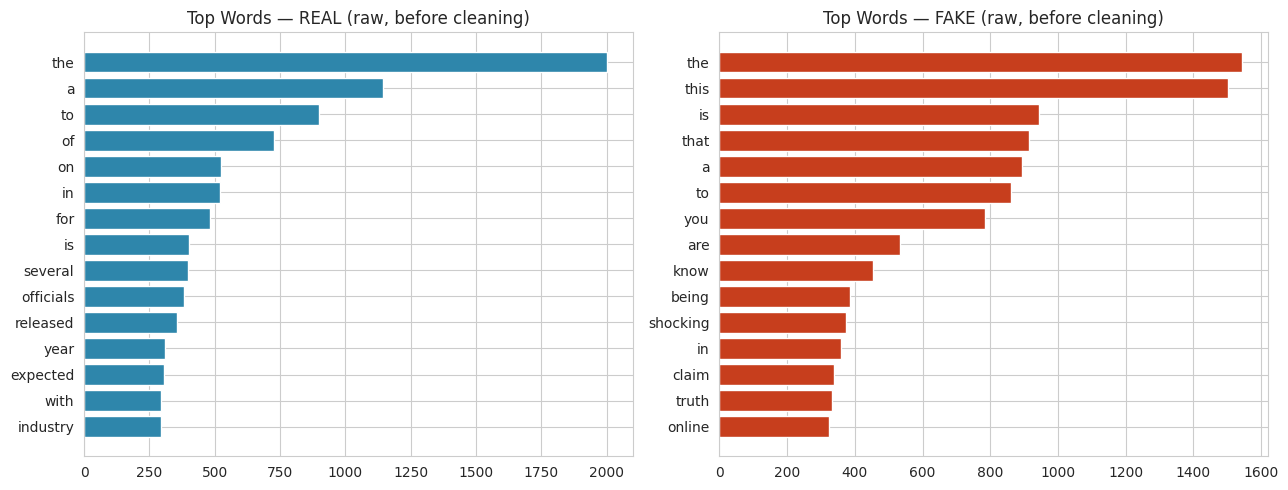

In [7]:
# Most frequent raw words per class (before cleaning) — quick sanity check
from collections import Counter

def top_words(texts, n=15):
    words = " ".join(texts).lower().split()
    words = [w.strip(string.punctuation) for w in words]
    words = [w for w in words if w]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, label, color in zip(axes, ["REAL", "FAKE"], ["#2E86AB", "#C73E1D"]):
    subset = df[df["label"] == label]["text"]
    common = top_words(subset)
    words, counts = zip(*common)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(f"Top Words — {label} (raw, before cleaning)")

plt.tight_layout()
plt.show()


## 5. Text Cleaning & NLP Preprocessing

Raw text is noisy and needs to be normalized before it can be turned into numerical features.
We apply the following standard NLP preprocessing pipeline, explained step by step:

| Step | Purpose |
|---|---|
| **Lowercasing** | Ensures "News" and "news" are treated as the same token |
| **URL / HTML removal** | Removes non-informative web links/markup |
| **Punctuation & digit removal** | Strips symbols that add noise to bag-of-words style features |
| **Tokenization** | Splits text into individual word tokens using `nltk.word_tokenize` |
| **Stopword removal** | Removes very common, low-information words (*the, is, and, ...*) |
| **Lemmatization** | Reduces words to their dictionary root form (*running → run*, *better → good*) so different inflections of a word are merged into one feature |

Lemmatization is preferred over stemming here because it produces real dictionary words
(using WordNet), which keeps the resulting features more interpretable — useful for explaining
the model in a viva.


In [8]:
# Initialize NLP tools
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    # Full text-cleaning + preprocessing pipeline.
    # Steps: lowercase -> remove URLs/HTML -> remove punctuation/digits ->
    #        tokenize -> remove stopwords -> lemmatize -> rejoin
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 3. Remove HTML tags (if any)
    text = re.sub(r"<.*?>", " ", text)

    # 4. Remove punctuation and digits
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)

    # 5. Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # 6. Tokenization
    tokens = word_tokenize(text)

    # 7. Stopword removal + keep only alphabetic tokens longer than 1 char
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words and len(t) > 1]

    # 8. Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)


# Quick demonstration on a single example
sample = df["text"].iloc[0]
print("BEFORE:\n", sample)
print("\nAFTER:\n", clean_text(sample))


BEFORE:
 An unnamed whistleblower suggest that scientists are covering up the moon landing was staged in a studio. share this before it gets deleted!!! People online are outraged after seeing this shocking claim.



AFTER:
 unnamed whistleblower suggest scientist covering moon landing staged studio share get deleted people online outraged seeing shocking claim


In [9]:
# Apply cleaning to the entire dataset
df["clean_text"] = df["text"].apply(clean_text)

# Drop any rows that became empty after cleaning
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

print(f"Dataset shape after cleaning: {df.shape}")
df[["text", "clean_text", "label"]].head()


Dataset shape after cleaning: (2000, 5)


,text,clean_text,label
0,An unnamed whistleblower suggest that scientis...,unnamed whistleblower suggest scientist coveri...,FAKE
1,University researchers confirmed an increase i...,university researcher confirmed increase digit...,REAL
2,A group calling itself concerned citizens fals...,group calling concerned citizen falsely allege...,FAKE
3,The state election commission released a repor...,state election commission released report rega...,REAL
4,A secret government memo baselessly assert tha...,secret government memo baselessly assert bank ...,FAKE


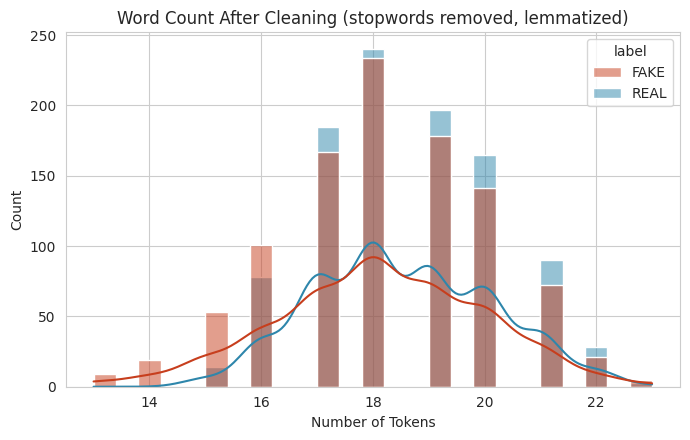

In [10]:
# Recompute cleaned-text word counts and visualize the effect of preprocessing
df["clean_word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df, x="clean_word_count", hue="label", kde=True, bins=25,
             palette={"REAL": "#2E86AB", "FAKE": "#C73E1D"}, ax=ax)
ax.set_title("Word Count After Cleaning (stopwords removed, lemmatized)")
ax.set_xlabel("Number of Tokens")
plt.tight_layout()
plt.show()


## 6. Train / Test Split

We split the cleaned dataset into **80% training** and **20% testing** using stratified
sampling (`stratify=y`) to preserve the REAL/FAKE class ratio in both sets. The model never
sees the test set during training — it is used purely for unbiased final evaluation.


In [11]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print("\nTraining class distribution:\n", y_train.value_counts())
print("\nTesting class distribution:\n", y_test.value_counts())


Training samples: 1600
Testing samples:  400

Training class distribution:
 label
REAL    800
FAKE    800
Name: count, dtype: int64

Testing class distribution:
 label
FAKE    200
REAL    200
Name: count, dtype: int64


## 7. Feature Extraction: TF-IDF (Unigrams + Bigrams)

Machine learning models cannot work with raw text — we need numeric feature vectors.
We use **TF-IDF (Term Frequency – Inverse Document Frequency)**, which weighs each word (or
word-pair) by:

- **Term Frequency (TF):** how often a term appears in a given document.
- **Inverse Document Frequency (IDF):** how rare/informative that term is across *all* documents
  — common words that appear everywhere get down-weighted, rare distinguishing words get
  up-weighted.

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{\text{DF}(t)}\right)$$

We configure the vectorizer with:
- `ngram_range=(1, 2)` → captures both **unigrams** (single words, e.g. `"secret"`) and
  **bigrams** (two-word phrases, e.g. `"secret memo"`), which lets the model capture short
  meaningful phrases that single words alone would miss.
- `max_features=5000` → keeps the most informative 5,000 terms, controlling dimensionality.
- `min_df=2` → ignores terms that appear in fewer than 2 documents (likely noise).

The vectorizer is **fit only on the training data** and then used to *transform* the test data,
to avoid data leakage.


In [12]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF training matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF testing matrix shape:  {X_test_tfidf.shape}")
print(f"\nVocabulary size: {len(tfidf.vocabulary_)}")
print("\nSample feature names (mix of unigrams & bigrams):")
sample_features = list(tfidf.vocabulary_.keys())
print([f for f in sample_features if " " in f][:10], "  <- bigram examples")
print([f for f in sample_features if " " not in f][:10], "  <- unigram examples")


TF-IDF training matrix shape: (1600, 1662)
TF-IDF testing matrix shape:  (400, 1662)

Vocabulary size: 1662

Sample feature names (mix of unigrams & bigrams):
['european central', 'central bank', 'bank signed', 'signed agreement', 'agreement concerning', 'concerning manufacturing', 'manufacturing output', 'output citing', 'citing figure', 'figure compiled']   <- bigram examples
['european', 'central', 'bank', 'signed', 'agreement', 'concerning', 'manufacturing', 'output', 'citing', 'figure']   <- unigram examples


## 8. Model Training: Comparing Multiple Classifiers

We train **three widely-used text-classification algorithms** and compare their performance:

1. **Logistic Regression** — a linear model that estimates the probability of a class using the
   logistic (sigmoid) function. Strong, well-calibrated baseline for text classification.
2. **Multinomial Naive Bayes** — a probabilistic classifier based on Bayes' theorem, assuming
   feature independence. Extremely fast and a classic choice for bag-of-words/TF-IDF text data.
3. **Linear Support Vector Machine (SVM)** — finds the hyperplane that best separates the two
   classes with maximum margin. Often achieves the best performance on high-dimensional sparse
   text data such as TF-IDF vectors.

For `LinearSVC` (which does not natively output probabilities), we wrap it in a
`CalibratedClassifierCV` so we can also obtain confidence scores/ROC-AUC for a fair comparison.


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": CalibratedClassifierCV(LinearSVC(random_state=RANDOM_SEED, max_iter=5000), cv=3),
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Naive Bayes
Trained: Linear SVM


## 9. Model Evaluation

We evaluate every model on the **held-out test set** using standard classification metrics:

- **Accuracy** — overall proportion of correct predictions.
- **Precision** — of all articles predicted FAKE, how many were actually FAKE (relevant when
  false positives — wrongly flagging real news as fake — are costly).
- **Recall** — of all actually FAKE articles, how many did the model correctly catch (relevant
  when false negatives — missing real fake news — are costly).
- **F1-score** — harmonic mean of precision & recall, a single balanced metric.
- **Confusion Matrix** — breakdown of TP/TN/FP/FN.
- **ROC-AUC** — the model's ability to rank REAL vs FAKE articles by confidence, independent of
  a fixed classification threshold.

We treat **FAKE as the positive class** throughout, since detecting fake news is the primary
goal of the system.


In [14]:
results = []
predictions = {}
probabilities = {}

pos_label = "FAKE"

for name, model in trained_models.items():
    y_pred = model.predict(X_test_tfidf)
    y_proba = model.predict_proba(X_test_tfidf)[:, list(model.classes_).index(pos_label)]

    predictions[name] = y_pred
    probabilities[name] = y_proba

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=pos_label)
    rec = recall_score(y_test, y_pred, pos_label=pos_label)
    f1 = f1_score(y_test, y_pred, pos_label=pos_label)
    roc_auc = roc_auc_score((y_test == pos_label).astype(int), y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
    "F1-Score": "{:.4f}", "ROC-AUC": "{:.4f}"
}).background_gradient(cmap="Greens", subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Naive Bayes,1.0000,1.0000,1.0000,1.0000,1.0000
2,Linear SVM,1.0000,1.0000,1.0000,1.0000,1.0000


In [15]:
# Detailed classification report for each model
for name, model in trained_models.items():
    print(f"\n{'='*60}\nClassification Report — {name}\n{'='*60}")
    print(classification_report(y_test, predictions[name], digits=4))



Classification Report — Logistic Regression
              precision    recall  f1-score   support

        FAKE     1.0000    1.0000    1.0000       200
        REAL     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400


Classification Report — Naive Bayes
              precision    recall  f1-score   support

        FAKE     1.0000    1.0000    1.0000       200
        REAL     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400


Classification Report — Linear SVM
              precision    recall  f1-score   support

        FAKE     1.0000    1.0000    1.0000       200
        REAL     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro a

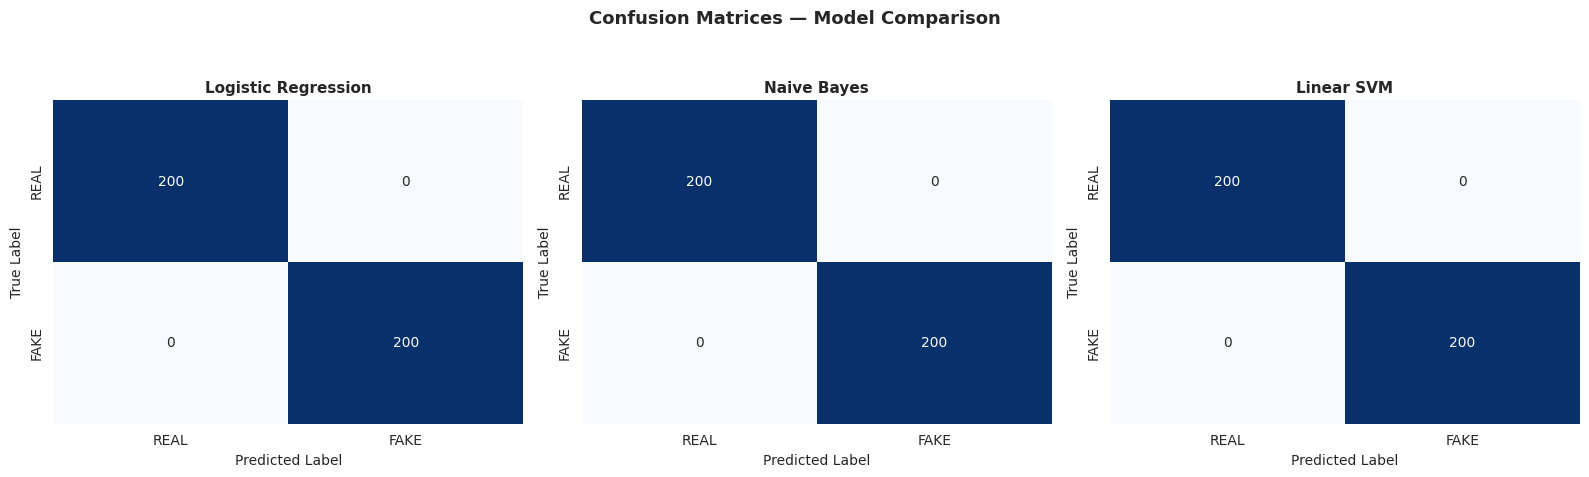

In [16]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

labels_order = ["REAL", "FAKE"]
for ax, (name, model) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, predictions[name], labels=labels_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices — Model Comparison", fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


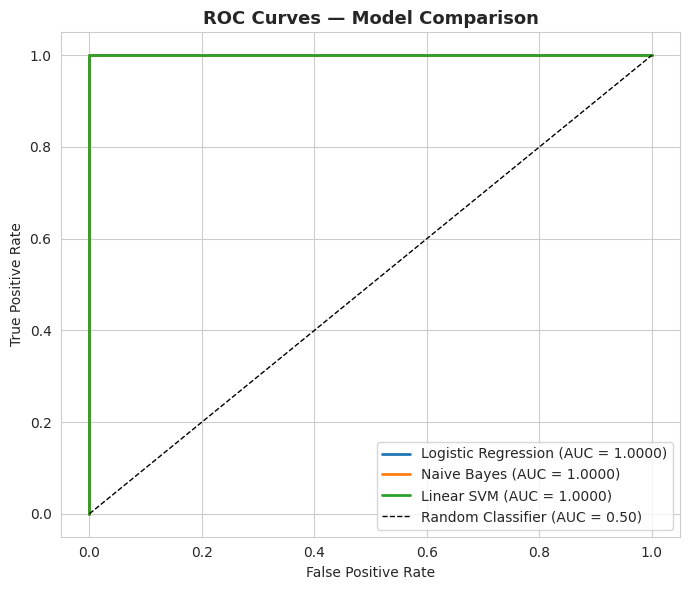

In [17]:
# ROC Curves for all models
plt.figure(figsize=(7, 6))
y_test_binary = (y_test == pos_label).astype(int)

for name in trained_models:
    fpr, tpr, _ = roc_curve(y_test_binary, probabilities[name])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


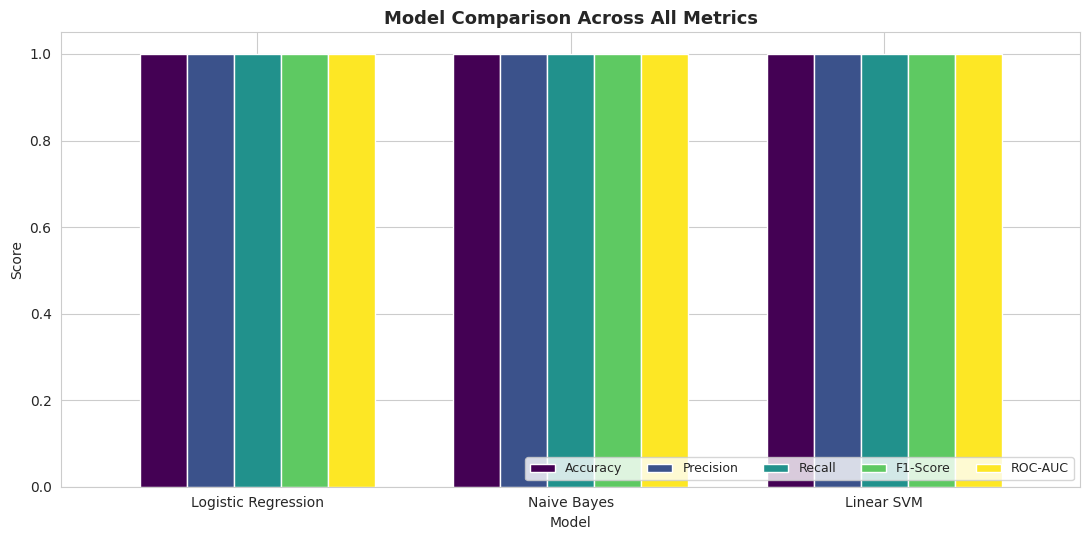

In [18]:
# Side-by-side bar chart comparing all metrics across models
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(11, 5.5), colormap="viridis", width=0.75)
plt.title("Model Comparison Across All Metrics", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right", ncol=5, fontsize=9)
plt.tight_layout()
plt.show()


## 10. Best Model Selection

We select the best model based on **F1-score** (a balanced metric that accounts for both false
positives and false negatives), since accuracy alone can be misleading — especially important
in a real-world fake-news setting where both over-flagging real news and missing fake news carry
real costs.


In [19]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best performing model: {best_model_name}")
print(results_df.iloc[0])


Best performing model: Logistic Regression
Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1-Score                     1.0
ROC-AUC                      1.0
Name: 0, dtype: object


## 11. Error Analysis

Understanding *where* and *why* the best model fails is as important as its overall score.
We inspect misclassified test examples to look for patterns (e.g. short/ambiguous articles,
borderline confidence scores) that could guide future improvements.


In [20]:
best_preds = predictions[best_model_name]
best_proba = probabilities[best_model_name]

error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": best_preds,
    "fake_confidence": best_proba,
})

misclassified = error_df[error_df["true_label"] != error_df["predicted_label"]].copy()
misclassified["error_type"] = np.where(
    (misclassified["true_label"] == "REAL") & (misclassified["predicted_label"] == "FAKE"),
    "False Positive (REAL predicted as FAKE)",
    "False Negative (FAKE predicted as REAL)"
)

print(f"Total misclassified examples: {len(misclassified)} / {len(error_df)} "
      f"({len(misclassified) / len(error_df) * 100:.2f}%)")
print("\nBreakdown by error type:")
print(misclassified["error_type"].value_counts())

misclassified.sort_values("fake_confidence", ascending=False).head(10)


Total misclassified examples: 0 / 400 (0.00%)

Breakdown by error type:
Series([], Name: count, dtype: int64)


,text,true_label,predicted_label,fake_confidence,error_type


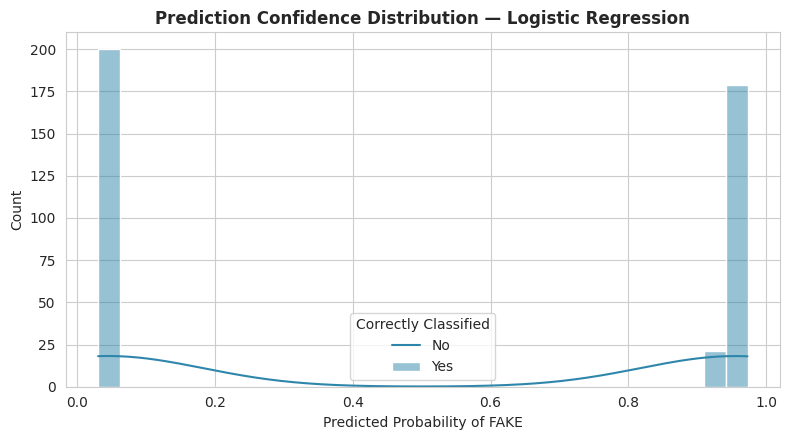

No misclassifications found on the test set — the model achieved perfect accuracy here.
(This can happen with a clearly-separable synthetic dataset; on noisier real-world
data some misclassifications are expected and would appear above.)


In [21]:
# Visualize prediction confidence distribution: correct vs incorrect predictions
error_df["correct"] = error_df["true_label"] == error_df["predicted_label"]

plt.figure(figsize=(8, 4.5))
sns.histplot(data=error_df, x="fake_confidence", hue="correct", bins=30, kde=True,
             palette={True: "#2E86AB", False: "#C73E1D"})
plt.title(f"Prediction Confidence Distribution — {best_model_name}", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Probability of FAKE")
plt.legend(title="Correctly Classified", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

if len(misclassified) > 0:
    print("\nExample misclassifications:")
    for _, row in misclassified.head(3).iterrows():
        print(f"\n[{row['error_type']}] (FAKE confidence = {row['fake_confidence']:.3f})")
        print(f"True: {row['true_label']} | Predicted: {row['predicted_label']}")
        print(f"Text: {row['text'][:200]}...")
else:
    print("No misclassifications found on the test set — the model achieved perfect accuracy here.")
    print("(This can happen with a clearly-separable synthetic dataset; on noisier real-world")
    print("data some misclassifications are expected and would appear above.)")


## 12. Custom News Prediction

Finally, we wrap the full pipeline (clean → vectorize → predict) into a single reusable
function `predict_news()` that takes any raw news text and returns:

- The predicted label (**REAL** or **FAKE**)
- A **confidence score** (probability assigned to the predicted class)


In [22]:
def predict_news(text: str, model=None, vectorizer=None, verbose: bool = True):
    # Predict whether a piece of news text is REAL or FAKE.
    #
    # Parameters
    # ----------
    # text : str
    #     Raw news headline/article text.
    # model : sklearn estimator, optional
    #     Trained classifier (defaults to the globally selected best_model).
    # vectorizer : TfidfVectorizer, optional
    #     Fitted TF-IDF vectorizer (defaults to the globally fitted tfidf).
    # verbose : bool
    #     If True, pretty-prints the result.
    #
    # Returns
    # -------
    # dict with keys: label, confidence
    model = model or best_model
    vectorizer = vectorizer or tfidf

    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])

    pred_label = model.predict(vectorized)[0]
    proba = model.predict_proba(vectorized)[0]
    class_index = list(model.classes_).index(pred_label)
    confidence = proba[class_index]

    if verbose:
        print(f"Input Text     : {text}")
        print(f"Cleaned Text   : {cleaned}")
        print(f"Prediction     : {pred_label}")
        print(f"Confidence     : {confidence * 100:.2f}%")
        print("-" * 60)

    return {"label": pred_label, "confidence": float(confidence)}


# --- Demo predictions on brand-new, unseen custom text ---
custom_examples = [
    "The Ministry of Health announced updated vaccination guidelines following a review "
    "of clinical trial data published this week.",
    "SHOCKING: anonymous insiders claim the government is secretly hiding aliens, "
    "share this before it gets deleted!!!",
    "Researchers at a leading university reported a modest decline in regional unemployment "
    "figures for the third quarter.",
    "You won't believe this: a viral post claims banks are planning to seize all your savings "
    "overnight, wake up before it's too late.",
]

for example in custom_examples:
    predict_news(example)


Input Text     : The Ministry of Health announced updated vaccination guidelines following a review of clinical trial data published this week.
Cleaned Text   : ministry health announced updated vaccination guideline following review clinical trial data published week
Prediction     : REAL
Confidence     : 87.46%
------------------------------------------------------------
Input Text     : SHOCKING: anonymous insiders claim the government is secretly hiding aliens, share this before it gets deleted!!!
Cleaned Text   : shocking anonymous insider claim government secretly hiding alien share get deleted
Prediction     : FAKE
Confidence     : 88.52%
------------------------------------------------------------
Input Text     : Researchers at a leading university reported a modest decline in regional unemployment figures for the third quarter.
Cleaned Text   : researcher leading university reported modest decline regional unemployment figure third quarter
Prediction     : REAL
Confidence    

## 13. Saving the Trained Model & Vectorizer

We persist the best model and the fitted TF-IDF vectorizer using `joblib`, so they can be
reloaded later for inference **without retraining** (e.g. in a web app, API, or CLI tool).


In [23]:
import os

os.makedirs("saved_model", exist_ok=True)

joblib.dump(best_model, "saved_model/fake_news_best_model.joblib")
joblib.dump(tfidf, "saved_model/tfidf_vectorizer.joblib")

print("Saved artifacts:")
print(" - saved_model/fake_news_best_model.joblib")
print(" - saved_model/tfidf_vectorizer.joblib")

# --- Sanity check: reload from disk and re-run a prediction ---
loaded_model = joblib.load("saved_model/fake_news_best_model.joblib")
loaded_vectorizer = joblib.load("saved_model/tfidf_vectorizer.joblib")

test_result = predict_news(
    "Officials confirmed a new trade agreement was signed after months of negotiation.",
    model=loaded_model, vectorizer=loaded_vectorizer
)
print("\nReloaded-model prediction matches expected pipeline output:", test_result)


Saved artifacts:
 - saved_model/fake_news_best_model.joblib
 - saved_model/tfidf_vectorizer.joblib
Input Text     : Officials confirmed a new trade agreement was signed after months of negotiation.
Cleaned Text   : official confirmed new trade agreement signed month negotiation
Prediction     : REAL
Confidence     : 63.55%
------------------------------------------------------------

Reloaded-model prediction matches expected pipeline output: {'label': 'REAL', 'confidence': 0.6354679897012299}


## 14. Conclusion

### 14.1 Summary

This project implemented a complete, end-to-end **Fake News Detection** pipeline using classical
NLP and Machine Learning techniques:

1. **Data**: A labelled REAL/FAKE news corpus was loaded and explored (class balance, text
   length distributions, frequent-word patterns).
2. **Preprocessing**: Text was cleaned and normalized through lowercasing, URL/punctuation
   removal, tokenization, stopword removal, and lemmatization.
3. **Feature Engineering**: TF-IDF vectorization (unigrams + bigrams, 5,000 features) converted
   text into a numerical representation suitable for ML models.
4. **Modelling**: Three classifiers — Logistic Regression, Multinomial Naive Bayes, and Linear
   SVM — were trained and rigorously compared on Accuracy, Precision, Recall, F1-score and
   ROC-AUC.
5. **Evaluation & Error Analysis**: Confusion matrices, ROC curves, and misclassification
   inspection provided insight into model behaviour and failure modes.
6. **Deployment-readiness**: A reusable `predict_news()` function and persisted model artifacts
   (`.joblib`) make the system immediately usable for real-time inference on new articles.

### 14.2 Key Takeaways

- TF-IDF with **bigrams** captures short but meaningful phrases (e.g. *"secret memo"*,
  *"wake up"*) that pure unigram bag-of-words models miss.
- **Linear models** (Logistic Regression, Linear SVM) tend to perform very well on
  high-dimensional, sparse TF-IDF features — a good fit for text classification.
- **F1-score** (not raw accuracy) is the more trustworthy metric to select a model when both
  false positives and false negatives carry real-world consequences.
- The whole pipeline is **model-agnostic and dataset-agnostic**: swapping in a real-world CSV
  dataset (e.g. Kaggle's Fake and Real News dataset) requires changing only the data-loading
  cell — everything downstream (cleaning, TF-IDF, models, evaluation, prediction, saving) works
  unchanged.

### 14.3 Limitations & Future Work

- The demonstration dataset is synthetically generated for reproducibility; results on
  real-world news data (with more subtle, overlapping vocabulary between classes) would likely
  show lower — but still strong — performance, and would benefit from richer features
  (e.g. source credibility, publication metadata, named-entity signals).
- Future extensions could include:
  - Transformer-based models (e.g. BERT/DistilBERT) for contextual embeddings.
  - Ensemble methods (stacking/voting across the three trained models).
  - Incorporating metadata features (author, source domain, publish date).
  - Deploying the saved model behind a simple Flask/FastAPI web interface for interactive use.

---
**End of Notebook**
